<a href="https://colab.research.google.com/github/c4835/ML_02April/blob/main/360390_PB6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment:
### Urban Architecture Failure

In [2]:
# We will first import all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

#### Will load the data

In [3]:
# Will also first launch the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Lets access the data from google drive and import the file.
urban = pd.read_csv('/content/drive/MyDrive/ITNPBD6_Final_ML/urbandata.csv')
urban.head()    # To display first 5 rows of the imported dataset

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,inspection_season,inspection_window,moisture_stress,failure
0,5,31.762605,12.891996,4.711064,71.480592,9.429642,5.177088,2.9944,summer,afternoon,0.06,1
1,7,30.770158,11.835563,3.315888,60.300892,8.655641,4.927622,2.6808,spring,morning,0.01,0
2,6,31.591296,11.738267,2.425562,56.367965,9.017137,4.910945,2.5294,autumn,night,0.02,0
3,5,30.834649,11.622881,2.164486,53.135138,8.864650,4.949554,2.4810,autumn,afternoon,0.02,1
4,2,33.315981,12.616065,4.557082,77.482269,9.549344,5.047689,3.0460,summer,morning,0.07,1


In [5]:
# Lets find out the quanlity

print (f'Rows: {urban.shape[0]}')
print (f'Columns: {urban.shape[1]}')

Rows: 456
Columns: 12


In [6]:
print (urban.dtypes)    # to check the datatypes of the colums

inspector_id               int64
material_flexibility     float64
structural_mass_ratio    float64
recent_precipitation     float64
infrastructure_age       float64
surface_debris           float64
vibration_exposure       float64
asset_density            float64
inspection_season         object
inspection_window         object
moisture_stress          float64
failure                    int64
dtype: object


In [7]:
# As 'inspection_season' and 'inspection_window' are non-numerical columns
# Lets find out the uniq values in them

print (urban['inspection_season'].unique())
print (urban['inspection_window'].unique())
print (urban ['inspection_season'].value_counts())
print (urban ['inspection_window'].value_counts())

['summer' 'spring' 'autumn' 'winter' 'sumer']
['afternoon' 'morning' 'night' 'morni7ng']
inspection_season
summer    133
autumn    122
winter    115
spring     85
sumer       1
Name: count, dtype: int64
inspection_window
night        172
morning      148
afternoon    135
morni7ng       1
Name: count, dtype: int64


In [8]:
# As we clan clearly see there are some typos in the spellings we can replace them

urban['inspection_season'] = urban['inspection_season'].replace({'sumer': 'summer'})
urban['inspection_window'] = urban['inspection_window'].replace({'morni7ng': 'morning'})

# Will verify the changes

print (urban['inspection_season'].unique())
print (urban['inspection_window'].unique())
print (urban ['inspection_season'].value_counts())
print (urban ['inspection_window'].value_counts())

['summer' 'spring' 'autumn' 'winter']
['afternoon' 'morning' 'night']
inspection_season
summer    134
autumn    122
winter    115
spring     85
Name: count, dtype: int64
inspection_window
night        172
morning      149
afternoon    135
Name: count, dtype: int64


In [9]:
# To check the duplicates in row
print (f'Duplicate rows found: {urban.duplicated().sum()}')

Duplicate rows found: 0


In [10]:
# Lets check the missing values
print (urban.isnull().sum())

inspector_id             0
material_flexibility     0
structural_mass_ratio    1
recent_precipitation     2
infrastructure_age       4
surface_debris           0
vibration_exposure       1
asset_density            0
inspection_season        0
inspection_window        0
moisture_stress          3
failure                  0
dtype: int64


###### We have some null values, we can work on them after splitting the data to avoid the data leakage

In [11]:
# As we have already given a target Variable, lets seperate Features & Target Columns before we split the data

X = urban.drop(columns=['failure'])
y = urban['failure']

In [12]:
# Now will split the data into Training set, Validation set & Test set

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,   # It gives around 70/15/15 split
    random_state=42,
    stratify=y_temp
)

print(f"Train set: {X_train.shape[0]} rows")
print(f"Validation set: {X_val.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Train set: 318 rows
Validation set: 69 rows
Test set: 69 rows


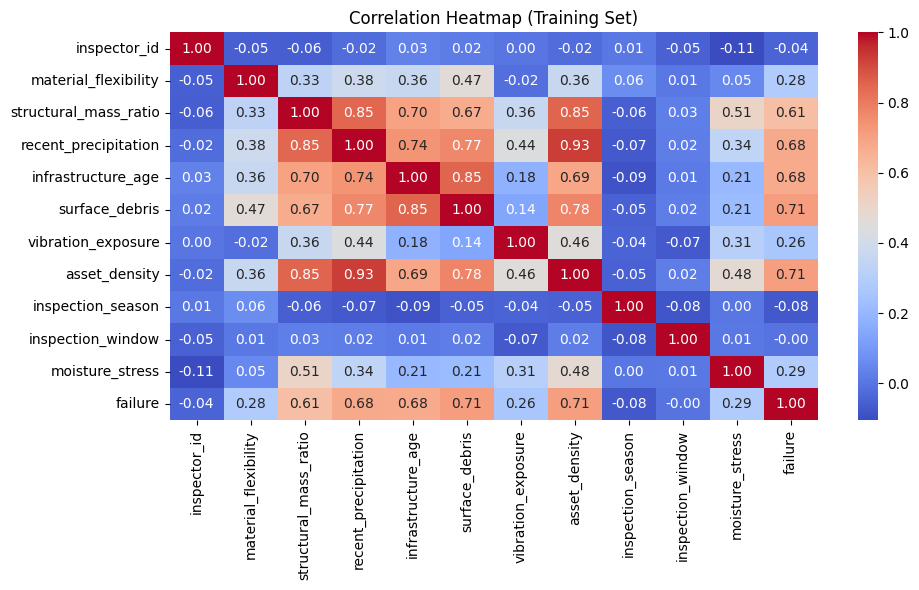

In [13]:
# Now lets check the correlation heatmap on training set only
train_eda_df = X_train.copy()

# We will encode non-numerical categories temporarily only for correlation inspection
train_eda_df['inspection_season'] = train_eda_df['inspection_season'].astype('category').cat.codes
train_eda_df['inspection_window'] = train_eda_df['inspection_window'].astype('category').cat.codes
train_eda_df['failure'] = y_train.values

plt.figure(figsize=(10, 6))
sns.heatmap(train_eda_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Training Set)')
plt.tight_layout()
plt.show()

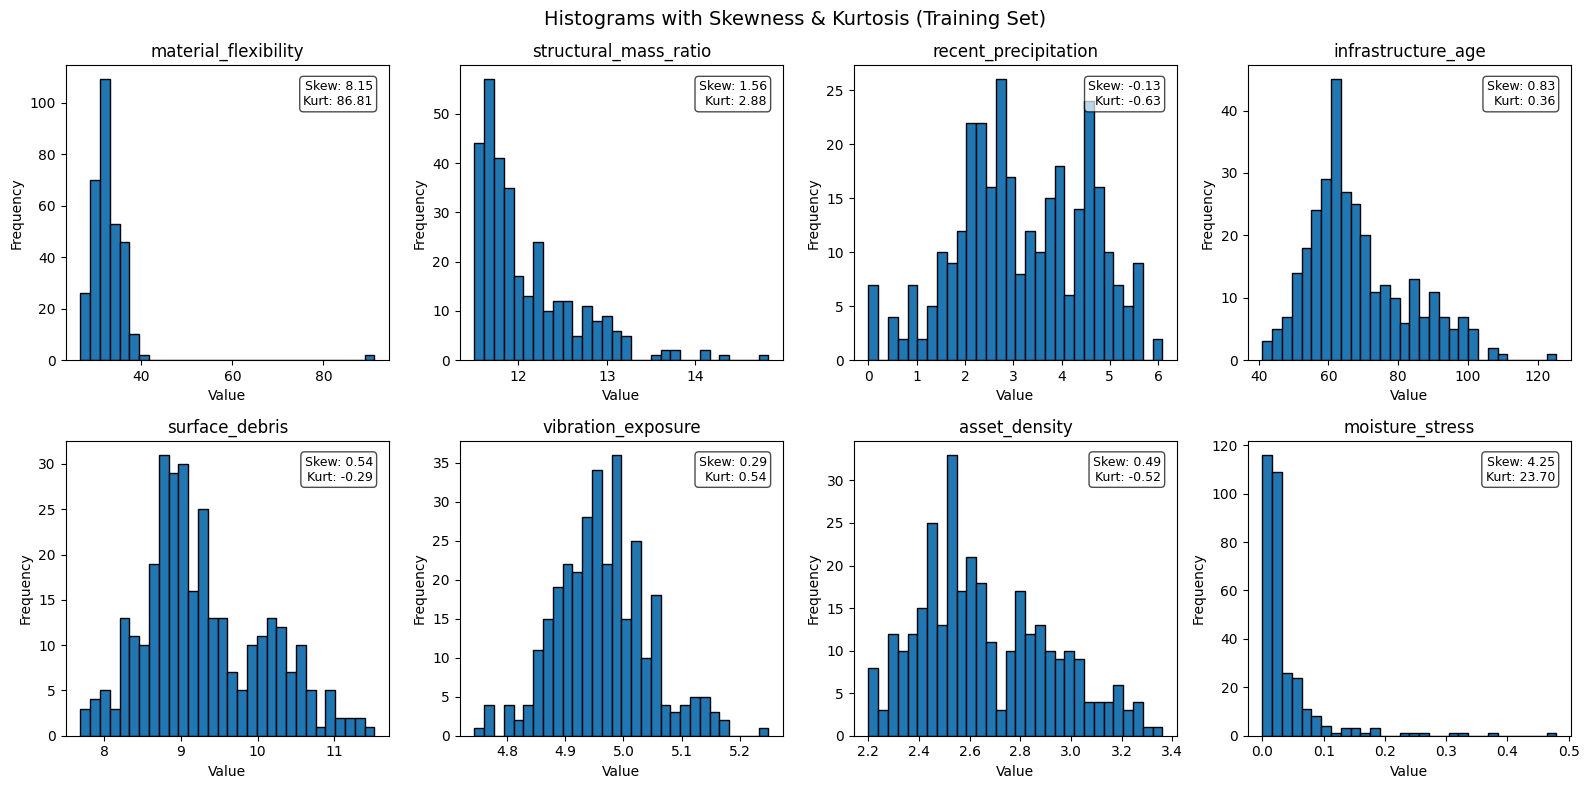

In [14]:
# Lets find out the data distribution of all the numeric columns
# First we will seperate the numeric columns
numeric_cols = [
    'material_flexibility',
    'structural_mass_ratio',
    'recent_precipitation',
    'infrastructure_age',
    'surface_debris',
    'vibration_exposure',
    'asset_density',
    'moisture_stress'
]

# Histograms WITH skewness & kurtosis (training set only)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Histograms with Skewness & Kurtosis (Training Set)', fontsize=14)

for i, col in enumerate(numeric_cols):
    row = i // 4
    col_idx = i % 4
    ax = axes[row, col_idx]

    ax.hist(X_train[col].dropna(), bins=30, edgecolor='black')

    skew_val = X_train[col].skew()
    kurt_val = X_train[col].kurt()

    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

    ax.text(
        0.95, 0.95,
        f"Skew: {skew_val:.2f}\nKurt: {kurt_val:.2f}",
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

plt.tight_layout()
plt.show()

In [17]:
# Lets handle the missing data now for training set

# These are the columns with missing values.
cols_with_missing = [
    'structural_mass_ratio',
    'recent_precipitation',
    'infrastructure_age',
    'vibration_exposure',
    'moisture_stress'
]

# Will make the copy of each set to avoid the changes in original set.
X_train_clean = X_train.copy()
X_val_clean = X_val.copy()
X_test_clean = X_test.copy()

train_medians = {}

# Will use the loop to calculate the median and impute the null values.
for col in cols_with_missing:
    median_val = X_train_clean[col].median()
    train_medians[col] = median_val

    X_train_clean[col] = X_train_clean[col].fillna(median_val)

    # Will do same imputation of median in validation and test set to keep consistancy and avoid data leakage.
    X_val_clean[col] = X_val_clean[col].fillna(median_val)
    X_test_clean[col] = X_test_clean[col].fillna(median_val)

print("Training set median used for each column")
for col, val in train_medians.items():
    print(f"{col}: {val:.4f}")


Training set median used for each column
structural_mass_ratio: 11.8818
recent_precipitation: 3.0033
infrastructure_age: 64.8675
vibration_exposure: 4.9608
moisture_stress: 0.0200


In [18]:
# Now lets validate the change in training data

print (X_train_clean.isnull().sum())

inspector_id             0
material_flexibility     0
structural_mass_ratio    0
recent_precipitation     0
infrastructure_age       0
surface_debris           0
vibration_exposure       0
asset_density            0
inspection_season        0
inspection_window        0
moisture_stress          0
dtype: int64
